In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

plt.style.use("ggplot")

trace = "85479ef37b5dc75dd5aeca3bab499129b97a134dac5d740d2c68941de9d63031"
t2 = "734272c01926d19690e5ec308bab64ef97950b75b1c7582283e0783fce1751d8"

df = pd.read_csv(
    "data/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
)


#df["end_timestamp"] = pd.to_timedelta(df["end_timestamp"], unit="seconds")
df["start_timestamp"] = df["end_timestamp"] - df["duration"]
df

,app,func,end_timestamp,duration,start_timestamp
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,7.949090e-02,0.078,1.490900e-03
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,5.715786e+01,57.154,3.860041e-03
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,5.913048e+01,59.125,5.477905e-03
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541e+00,6.236,1.654107e-02
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,6.682396e-02,0.050,1.682396e-02
...,...,...,...,...,...
1980946,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209597e+06,0.001,1.209597e+06
1980947,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209598e+06,0.001,1.209598e+06
1980948,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06
1980949,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06


## Statistics on Az2021

In [13]:

df["duration"].describe()

count    1.980951e+06
mean     3.347944e+00
std      1.850717e+01
min      0.000000e+00
25%      1.000000e-03
50%      3.100000e-02
75%      3.720000e-01
max      5.786200e+02
Name: duration, dtype: float64

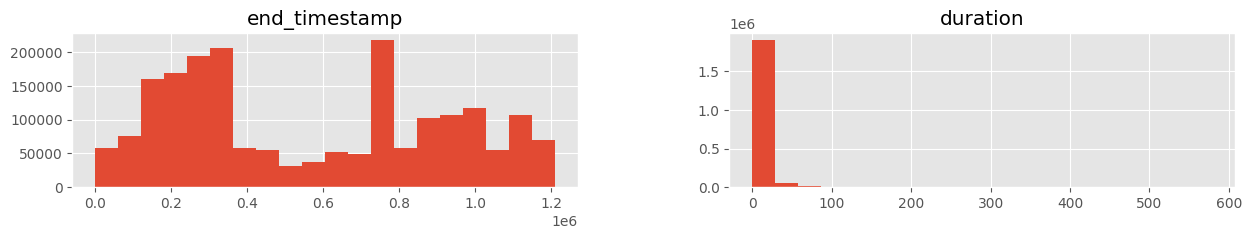

In [14]:
df.hist(column=["end_timestamp", "duration"], layout=[1, 2], figsize=[15, 2], bins=20)
plt.show()

# Duration distribution

In [15]:
def get_cdf(df, field):
    vals = sorted(df[field].values)
    invs = 100.0 * np.arange(0, len(df)) / len(df)
    return vals, invs

In [16]:
def plt_cdf(df, field="duration", title="Duration"):
    
    df_tokens, df_inv = get_cdf(df, field)
    plt.plot(df_tokens, df_inv)
    plt.title(title)
    plt.ylabel("CDF")
    plt.xlabel("Duration")
    plt.grid()
    plt.show()

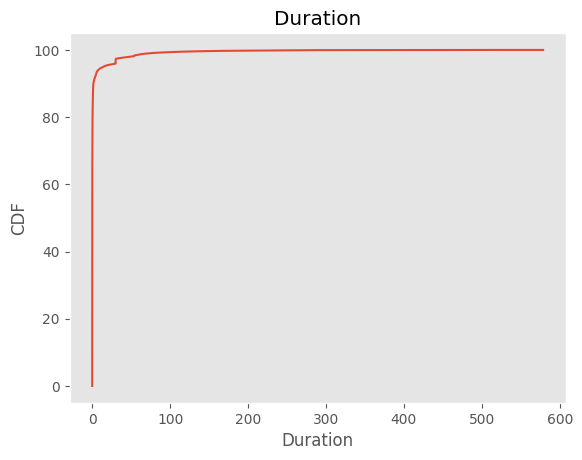

In [17]:
plt_cdf(df, field="duration")

In [18]:
print(f"unique apps: {df["app"].nunique()}, unique funcs: {df["func"].nunique()}")
df.groupby("app")["func"].count()
df.groupby("func")["app"].count()

unique apps: 119, unique funcs: 424


func
003e28b4c0625b5c25f565828f9674f4119a852b5a0c22742f28b03534e15d95    14
022cdd4cd3ed0302a5ca116eccf280f1d19680123d58e001d04630605ba3e1f8     1
03e6f2ee02dabf9c7d4706ed3eef31ba6cbb3749b2f80d5524de2ade586aec5c     1
04102340c9da533c95612233f432fbb64b4134e341d030e1c1ddb7f968c10a69     2
042581128a262e8c0e5f8e109eefaa9304cc97790bbce7f42f02aa37f2df1ae5     3
                                                                    ..
fc03862b1faad856099c02fa7633ae8153191729c9a2e49fa1ab2102bbe5fa17     1
fdc2b3a1df705e85aab1e13da29426410bace46b2c08eb3a6b34566193799528    10
ff64b4b0ac6a3b87f120eb5f53d69617b81f1f795608f97b8d1a25702cbdd67d     4
ffdbe7bea8e3695f904d67f0e224d86256bff06441473103ad81734a3bdbfe0c     6
fffac43a8d613c58f12b2f63e20c02949f946117af39318fc99649f16331cd5c     7
Name: app, Length: 424, dtype: int64

In [19]:
df2 = df[["app", "start_timestamp"]]
df2 = df2.loc[df2["app"] == trace]

df2["start_timestamp"] = pd.to_timedelta(df2["start_timestamp"], unit="seconds")
df2 = df2.set_index("start_timestamp")

dfc = df2.resample("10min").count()
print(dfc)

                            app
start_timestamp                
0 days 00:00:00.022979113    32
0 days 00:10:00.022979113    28
0 days 00:20:00.022979113    29
0 days 00:30:00.022979113    25
0 days 00:40:00.022979113    35
...                         ...
13 days 23:10:00.022979113   12
13 days 23:20:00.022979113    6
13 days 23:30:00.022979113   18
13 days 23:40:00.022979113    7
13 days 23:50:00.022979113   12

[2016 rows x 1 columns]


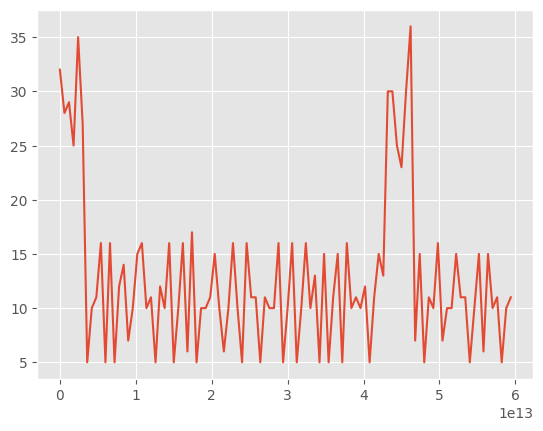

In [20]:

plt.style.use('ggplot')
plt.plot(dfc[:100].index, dfc[:100].values)

In [21]:
m = Prophet()
m.fit(dfc)

future = m.make_future_dataframe()
future.tail()

forecast = m.predict(future)

fig1 = m.plot(forecast)


ValueError: Dataframe must have columns "ds" and "y" with the dates and values respectively.